In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

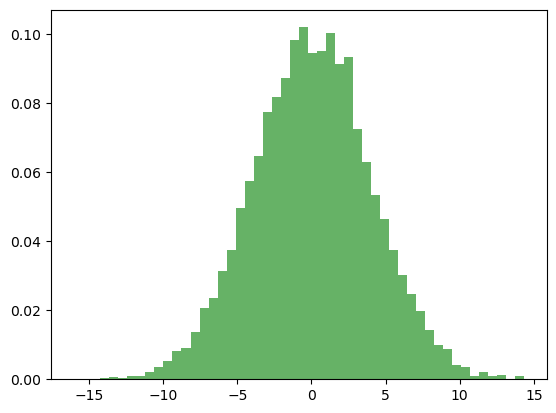

In [13]:
N = 10000

X = np.random.normal(size = N, loc = 0, scale = 4)
 
plt.hist(X, bins = 50, density = True, alpha = 0.6, color = 'g')
plt.show()

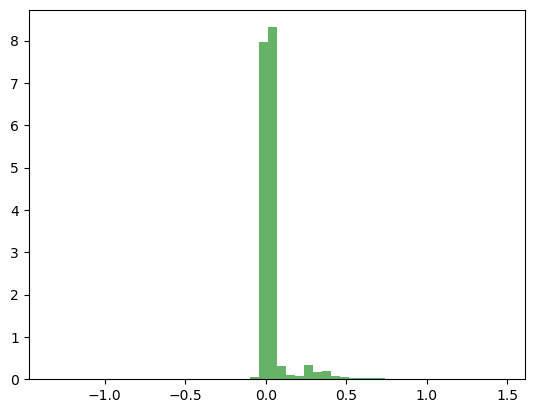

In [14]:
cummin = np.cumsum(X)
cumavg = cummin / np.arange(1, N+1)

cumavg

plt.hist(cumavg, bins = 50, density = True, alpha = 0.6, color = 'g')
plt.show()

In [15]:
cumavg = cummin / np.arange(1, N+1)

cum_std = np.sqrt(np.cumsum((X - cumavg)**2) / np.arange(1, N+1))



In [16]:
sets = [X, cumavg, cum_std]

for i in sets:
    print(f"Mean: {np.mean(i)}, Median: {np.median(i)}, Std: {np.std(i,ddof= 1)}")


Mean: 0.04736446799675388, Median: 0.044848948692385635, Std: 3.9762632128791826
Mean: 0.03600665012299919, Median: 0.014850894812127317, Std: 0.10097697002281525
Mean: 3.9733601156407437, Median: 3.9741971865424244, Std: 0.12933707951939272


Create a figure.

    Plot the cumulative average computed in point 3. as a line plot (where the x-axis represent the size of the sample considered, and the y-axis is the average).

    Add errorbars to each point in the graph with width equal to the standard error of the mean (the one you computed in point 4).
Add a horizontal line corresponding to the distribution mean (the one you found in point 5).

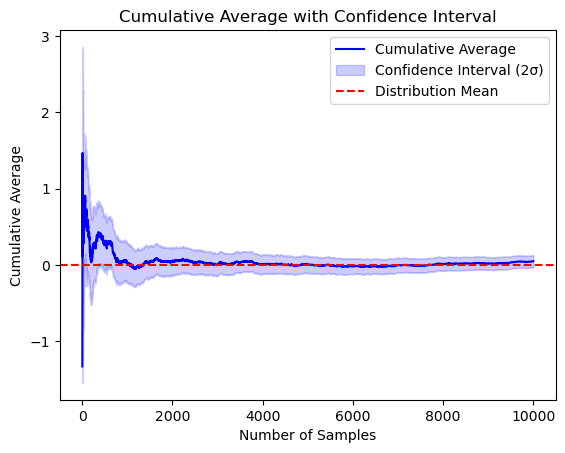

In [17]:
errobars = 2 * cum_std / np.sqrt(np.arange(1, N+1))
# Tegn den kumulative linje
plt.plot(np.arange(1, N+1), cumavg, label='Cumulative Average', color='blue')

# Lav et skyggeområde i stedet for error bars
plt.fill_between(np.arange(1, N+1), 
                 cumavg - errobars, 
                 cumavg + errobars, 
                 color='blue', alpha=0.2, label='Confidence Interval (2σ)')

# Din røde gennemsnitslinje
plt.axhline(y=0, color='r', linestyle='--', label='Distribution Mean')
plt.legend()
plt.xlabel('Number of Samples')
plt.ylabel('Cumulative Average')
plt.title('Cumulative Average with Confidence Interval')
plt.show()

In [18]:
lst = [np.mean(X[0:i]) for i in range(1, len(X) + 1)]
median_arr = np.array(lst)
median_arr

array([-1.33381086, -0.3363715 ,  0.55671736, ...,  0.04836284,
        0.04786889,  0.04736447], shape=(10000,))

### Pareto time

Create a figure.

    Plot the cumulative average computed in point 3. as a line plot (where the x-axis represent the size of the sample considered, and the y-axis is the average).

    Add errorbars to each point in the graph with width equal to the standard error of the mean (the one you computed in point 4).
Add a horizontal line corresponding to the distribution mean (the one you found in point 5).

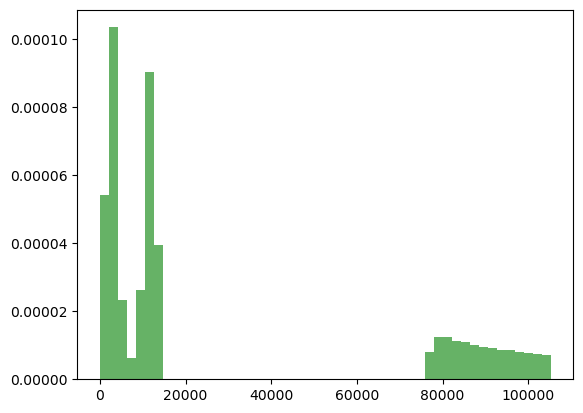

Mean: 76821.08190896599, Median: 3.0893262185783694, Std: 6769737.844265328
Mean: 29717.49357369281, Median: 10870.095236069652, Std: 37270.11891508137
Mean: 2267840.193867327, Median: 661097.7477323106, Std: 3133681.055068654


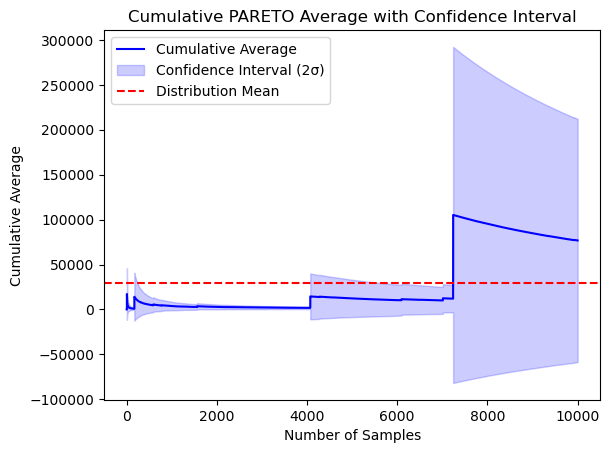

In [19]:
X_pareto = np.random.pareto(a = 0.5, size = N)*1
cummin = np.cumsum(X_pareto)
cumavg = cummin / np.arange(1, N+1)

cumavg

plt.hist(cumavg, bins = 50, density = True, alpha = 0.6, color = 'g')
plt.show()
cumavg = cummin / np.arange(1, N+1)

cum_std = np.sqrt(np.cumsum((X_pareto - cumavg)**2) / np.arange(1, N+1))
sets = [X_pareto, cumavg, cum_std]

for i in sets:
    print(f"Mean: {np.mean(i)}, Median: {np.median(i)}, Std: {np.std(i,ddof= 1)}")
errobars = 2 * cum_std / np.sqrt(np.arange(1, N+1))
# Tegn den kumulative linje
plt.plot(np.arange(1, N+1), cumavg, label='Cumulative Average', color='blue')

# Lav et skyggeområde i stedet for error bars
plt.fill_between(np.arange(1, N+1), 
                 cumavg - errobars, 
                 cumavg + errobars, 
                 color='blue', alpha=0.2, label='Confidence Interval (2σ)')

# Din røde gennemsnitslinje
plt.axhline(y=np.mean(cumavg), color='r', linestyle='--', label='Distribution Mean')
plt.legend()
plt.xlabel('Number of Samples')
plt.ylabel('Cumulative Average')
plt.title('Cumulative PARETO Average with Confidence Interval')
plt.show()

In [20]:
lst = [np.mean(X_pareto[0:i]) for i in range(1, len(X_pareto) + 1)]
pareto_median_arr = np.array(lst)
pareto_median_arr

array([1.10750336e+00, 6.13919130e-01, 5.45107000e+00, ...,
       7.68364492e+04, 7.68287648e+04, 7.68210819e+04], shape=(10000,))

### papers

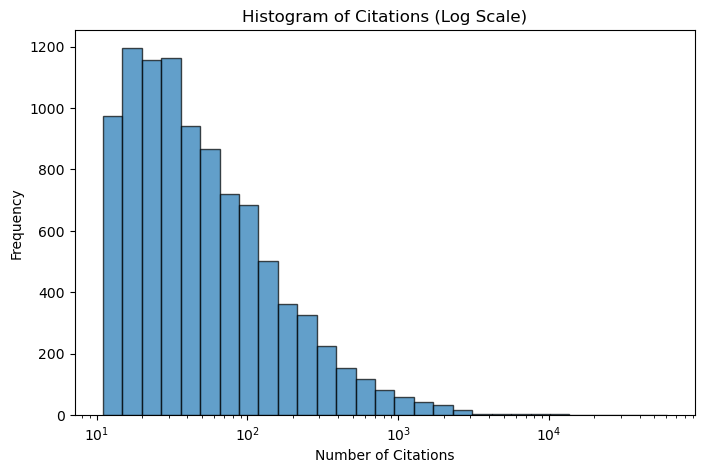

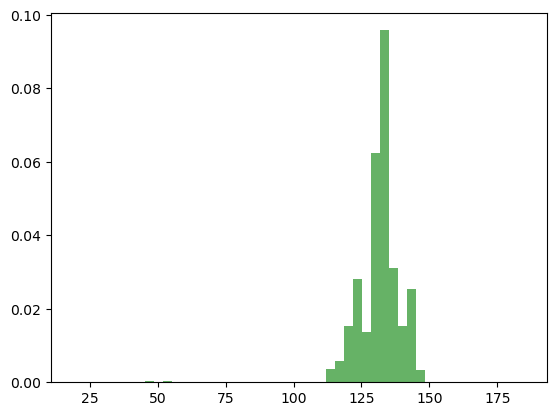

Mean: 131.2728, Median: 38.0, Std: 957.8238532389676
Mean: 131.70758440427676, Median: 132.50717848521282, Std: 8.122232007208588
Mean: 825.9507393766241, Median: 920.962088683887, Std: 261.5170894393139


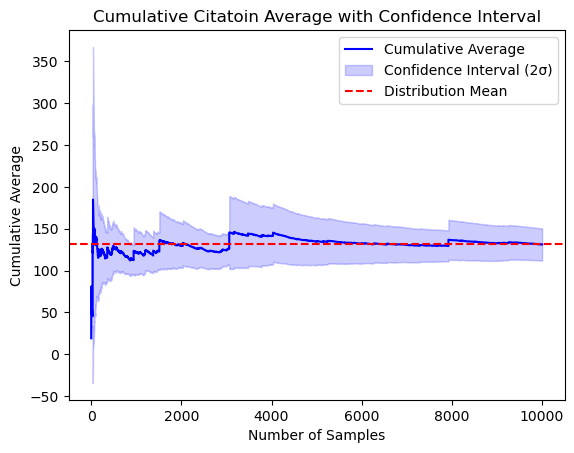

In [21]:
D2 = pd.read_csv('Ex3_D2.csv')

#Retrieve 10.000 random citaitons

random_citations = D2['cited_by_count'].sample(n=10000)

X = random_citations
bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 30)

plt.figure(figsize=(8, 5))
plt.hist(X, bins=bins, edgecolor='black', alpha=0.7)
plt.xscale('log')
plt.xlabel('Number of Citations')   
plt.ylabel('Frequency')
plt.title('Histogram of Citations (Log Scale)')
plt.show()
cummin = np.cumsum(X)
cumavg = cummin / np.arange(1, len(X)+1)

cumavg

plt.hist(cumavg, bins = 50, density = True, alpha = 0.6, color = 'g')
plt.show()
cumavg = cummin / np.arange(1, len(X)+1)

cum_std = np.sqrt(np.cumsum((X - cumavg)**2) / np.arange(1, len(X)+1))
sets = [X, cumavg, cum_std]

for i in sets:
    print(f"Mean: {np.mean(i)}, Median: {np.median(i)}, Std: {np.std(i,ddof= 1)}")
errobars = 2 * cum_std / np.sqrt(np.arange(1, len(X)+1))
# Tegn den kumulative linje
plt.plot(np.arange(1, len(X)+1), cumavg, label='Cumulative Average', color='blue')

# Lav et skyggeområde i stedet for error bars
plt.fill_between(np.arange(1, len(X)+1), 
                 cumavg - errobars, 
                 cumavg + errobars, 
                 color='blue', alpha=0.2, label='Confidence Interval (2σ)')

# Din røde gennemsnitslinje
plt.axhline(y=np.mean(cumavg), color='r', linestyle='--', label='Distribution Mean')
plt.legend()
plt.xlabel('Number of Samples')
plt.ylabel('Cumulative Average')
plt.title('Cumulative Citatoin Average with Confidence Interval')
plt.show()

### Compare the behavior of the cumulative average for Gaussian and Pareto distributions. What differences do you notice, and how do they align with your expectations?
Assess the cumulative median against the cumulative average across the two distributions. What insights can you gather about the utility of mean versus median in these contexts?
Based on your citation count data analysis, what observations can you make? What implications do these observations have?
Conclude with your key takeaways from this exercise.

Median is much more robust than mean for asesing the normal values

for normal dist median = mean = $\mu$ 

whereas the mean in pareto is $\inf$ and the median is $x_m \sqrt[\alpha](2)$


Our citations follow more a pareto distribution that a normal distribution

,Unnamed: 0,id,publication_year,cited_by_count,author_ids
0,0,https://openalex.org/W2962772482,2019.0,4400,"['A5091251187', 'A5003777693', 'A5071524745', ..."
1,1,https://openalex.org/W2043890595,2006.0,1182,"['A5025218537', 'A5014662127', 'A5061287527', ..."
2,2,https://openalex.org/W1989597713,2009.0,1169,"['A5071165387', 'A5037969281']"
3,3,https://openalex.org/W2012580531,2007.0,1009,"['A5024505700', 'A5009248582', 'A5036237095', ..."
4,4,https://openalex.org/W2146530408,2007.0,853,"['A5025218537', 'A5016146759', 'A5046546654']"
...,...,...,...,...,...
17264,17264,https://openalex.org/W178970892,2008.0,12,"['A5045660489', 'A5066593080', 'A5053264719', ..."
17265,17265,https://openalex.org/W2788267636,2018.0,12,"['A5100451855', 'A5100431792', 'A5100391493', ..."
17266,17266,https://openalex.org/W4287773562,2020.0,12,"['A5050370761', 'A5007782249', 'A5039596937', ..."
17267,17267,https://openalex.org/W2950945979,2012.0,11,"['A5100407758', 'A5006294869', 'A5033588812', ..."
